<a href="https://colab.research.google.com/github/AndreiMatosha/ML-Basic/blob/main/homework_09.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 🔬 Breast Cancer Wisconsin — EDA & kNN Модель

**Датасет:** Breast Cancer Wisconsin (Diagnostic) Data Set  
**Задача:** Бинарная классификация — злокачественная (M) или доброкачественная (B) опухоль

---

## ⚙️ Импорт библиотек

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
from scipy import stats

from sklearn.model_selection import train_test_split, cross_val_score, GridSearchCV, StratifiedKFold
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    roc_auc_score, roc_curve, confusion_matrix, classification_report
)

# Стиль визуализаций
sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams['figure.dpi'] = 100
plt.rcParams['font.size'] = 11

PALETTE = {'M': '#e74c3c', 'B': '#2ecc71'}
RANDOM_STATE = 42

print('Библиотеки успешно импортированы ✅')

Библиотеки успешно импортированы ✅


---
# Часть 1. Exploratory Data Analysis (EDA)

## 1.1 Загрузка и первичный осмотр данных

In [2]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("uciml/breast-cancer-wisconsin-data")

print("Path to dataset files:", path)

100%|██████████| 48.6k/48.6k [00:00<00:00, 1.21MB/s]

Extracting files...
Path to dataset files: /root/.cache/kagglehub/datasets/uciml/breast-cancer-wisconsin-data/versions/2


In [3]:
df = pd.read_csv('/root/.cache/kagglehub/datasets/uciml/breast-cancer-wisconsin-data/versions/2/data.csv')

# Убираем пустой столбец (если есть) и id
df = df.drop(columns=[col for col in df.columns if 'Unnamed' in str(col)], errors='ignore')
df = df.drop(columns=['id'], errors='ignore')

print(f'Форма датасета: {df.shape}')
print(f'\nПервые 5 строк:')
df.head()

Форма датасета: (569, 31)

Первые 5 строк:


,diagnosis,radius_mean,texture_mean,perimeter_mean,area_mean,smoothness_mean,compactness_mean,concavity_mean,concave points_mean,symmetry_mean,...,radius_worst,texture_worst,perimeter_worst,area_worst,smoothness_worst,compactness_worst,concavity_worst,concave points_worst,symmetry_worst,fractal_dimension_worst
0,M,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,0.2419,...,25.38,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890
1,M,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,0.1812,...,24.99,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902
2,M,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,0.2069,...,23.57,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758
3,M,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,0.2597,...,14.91,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300
4,M,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,0.1809,...,22.54,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678


In [4]:
print('Типы данных и пропуски:')
print(df.info())
print(f'\nПропущенные значения:\n{df.isnull().sum()[df.isnull().sum() > 0]}')

Типы данных и пропуски:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 569 entries, 0 to 568
Data columns (total 31 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   diagnosis                569 non-null    object 
 1   radius_mean              569 non-null    float64
 2   texture_mean             569 non-null    float64
 3   perimeter_mean           569 non-null    float64
 4   area_mean                569 non-null    float64
 5   smoothness_mean          569 non-null    float64
 6   compactness_mean         569 non-null    float64
 7   concavity_mean           569 non-null    float64
 8   concave points_mean      569 non-null    float64
 9   symmetry_mean            569 non-null    float64
 10  fractal_dimension_mean   569 non-null    float64
 11  radius_se                569 non-null    float64
 12  texture_se               569 non-null    float64
 13  perimeter_se             569 non-null    float64
 14  ar

Распределение целевой переменной:
diagnosis
B    357
M    212
Name: count, dtype: int64

Доля злокачественных (M): 37.3%
Доля доброкачественных (B): 62.7%


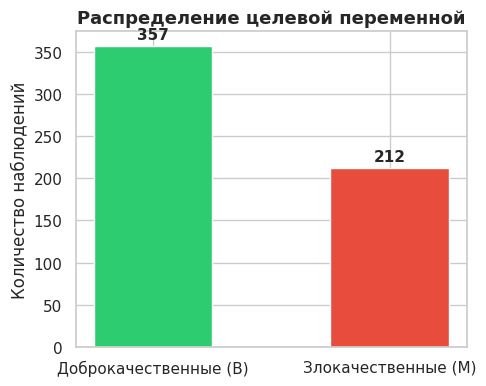

In [7]:
# Распределение целевой переменной
counts = df['diagnosis'].value_counts()
print('Распределение целевой переменной:')
print(counts)
print(f'\nДоля злокачественных (M): {counts["M"]/len(df)*100:.1f}%')
print(f'Доля доброкачественных (B): {counts["B"]/len(df)*100:.1f}%')

fig, ax = plt.subplots(figsize=(5, 4))
bars = ax.bar(['Доброкачественные (B)', 'Злокачественные (M)'],
              [counts['B'], counts['M']],
              color=[PALETTE['B'], PALETTE['M']], edgecolor='white', width=0.5)
for bar, cnt in zip(bars, [counts['B'], counts['M']]):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 5,
            str(cnt), ha='center', va='bottom', fontweight='bold')
ax.set_title('Распределение целевой переменной', fontsize=13, fontweight='bold')
ax.set_ylabel('Количество наблюдений')
plt.tight_layout()
plt.show()

## 1.2 Базовые статистики датасета

In [8]:
features = df.drop(columns=['diagnosis'])

stats_df = features.describe().T
stats_df['median'] = features.median()
stats_df['skewness'] = features.skew()
stats_df['kurtosis'] = features.kurtosis()
stats_df = stats_df[['count', 'mean', 'median', 'std', 'min', '25%', '75%', 'max', 'skewness', 'kurtosis']]
stats_df.columns = ['N', 'Mean', 'Median', 'Std', 'Min', 'Q1', 'Q3', 'Max', 'Skewness', 'Kurtosis']

print('Базовые статистики по всем признакам:')
stats_df.round(4)

Базовые статистики по всем признакам:


,N,Mean,Median,Std,Min,Q1,Q3,Max,Skewness,Kurtosis
radius_mean,569.0,14.1273,13.3700,3.5240,6.9810,11.7000,15.7800,28.1100,0.9424,0.8455
texture_mean,569.0,19.2896,18.8400,4.3010,9.7100,16.1700,21.8000,39.2800,0.6504,0.7583
perimeter_mean,569.0,91.9690,86.2400,24.2990,43.7900,75.1700,104.1000,188.5000,0.9907,0.9722
area_mean,569.0,654.8891,551.1000,351.9141,143.5000,420.3000,782.7000,2501.0000,1.6457,3.6523
smoothness_mean,569.0,0.0964,0.0959,0.0141,0.0526,0.0864,0.1053,0.1634,0.4563,0.8560
compactness_mean,569.0,0.1043,0.0926,0.0528,0.0194,0.0649,0.1304,0.3454,1.1901,1.6501
concavity_mean,569.0,0.0888,0.0615,0.0797,0.0000,0.0296,0.1307,0.4268,1.4012,1.9986
concave points_mean,569.0,0.0489,0.0335,0.0388,0.0000,0.0203,0.0740,0.2012,1.1712,1.0666
symmetry_mean,569.0,0.1812,0.1792,0.0274,0.1060,0.1619,0.1957,0.3040,0.7256,1.2879
fractal_dimension_mean,569.0,0.0628,0.0615,0.0071,0.0500,0.0577,0.0661,0.0974,1.3045,3.0059


In [9]:
print('Средние значения по группам (M vs B):')
group_stats = df.groupby('diagnosis')[features.columns].mean().T
group_stats['Ratio_M_B'] = group_stats['M'] / group_stats['B']
group_stats.sort_values('Ratio_M_B', ascending=False).round(3)

Средние значения по группам (M vs B):


diagnosis,B,M,Ratio_M_B
concavity_mean,0.046,0.161,3.491
area_se,21.135,72.672,3.438
concave points_mean,0.026,0.088,3.421
concavity_worst,0.166,0.451,2.711
area_worst,558.899,1422.286,2.545
concave points_worst,0.074,0.182,2.448
perimeter_se,2.000,4.324,2.162
radius_se,0.284,0.609,2.144
area_mean,462.790,978.376,2.114
compactness_worst,0.183,0.375,2.052


## 1.3 Гистограммы признаков с разбивкой по целевой переменной

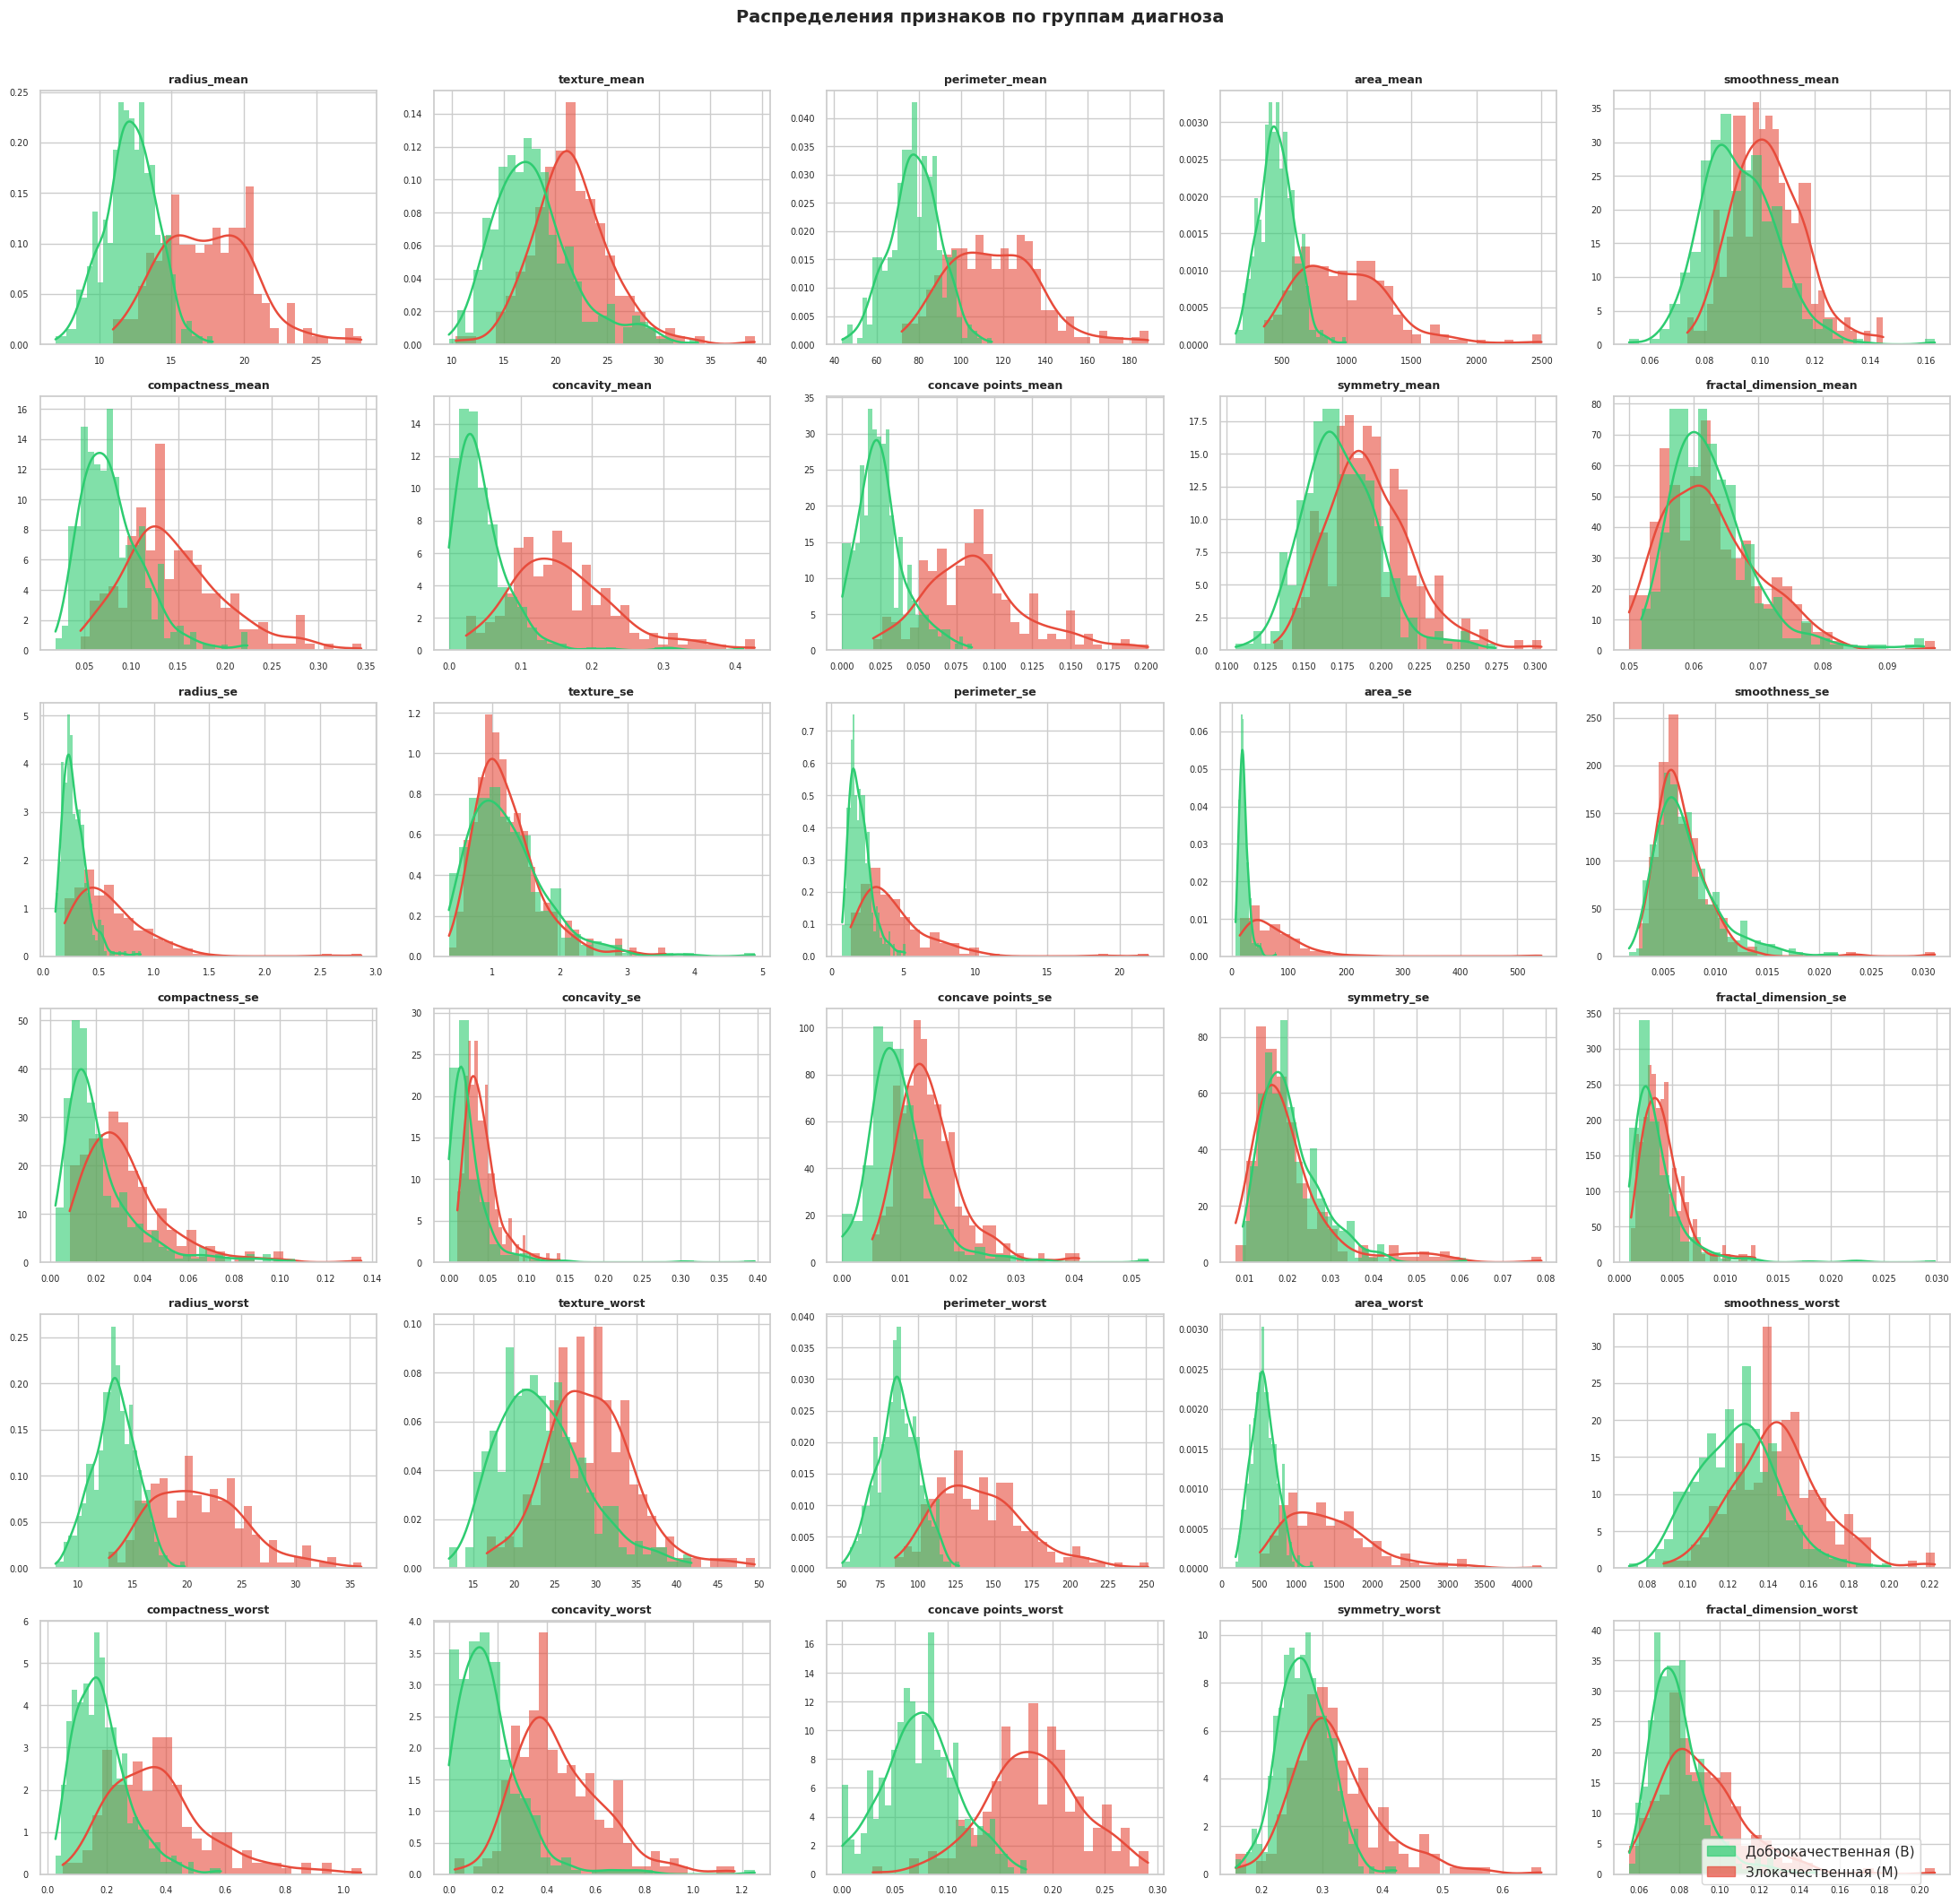

In [10]:
feature_cols = features.columns.tolist()
n_cols = 5
n_rows = (len(feature_cols) + n_cols - 1) // n_cols

fig, axes = plt.subplots(n_rows, n_cols, figsize=(22, n_rows * 3.5))
axes = axes.flatten()

for i, col in enumerate(feature_cols):
    ax = axes[i]
    for diag, color in PALETTE.items():
        subset = df[df['diagnosis'] == diag][col]
        ax.hist(subset, bins=30, alpha=0.6, color=color,
                label='Злокачественная (M)' if diag == 'M' else 'Доброкачественная (B)',
                density=True, edgecolor='none')
        # Добавляем KDE
        from scipy.stats import gaussian_kde
        kde = gaussian_kde(subset)
        x_range = np.linspace(subset.min(), subset.max(), 200)
        ax.plot(x_range, kde(x_range), color=color, lw=1.8)
    ax.set_title(col, fontsize=9, fontweight='bold')
    ax.set_xlabel('')
    ax.tick_params(labelsize=7)

# Убираем лишние оси
for j in range(i + 1, len(axes)):
    axes[j].set_visible(False)

legend_handles = [
    mpatches.Patch(color=PALETTE['B'], alpha=0.7, label='Доброкачественная (B)'),
    mpatches.Patch(color=PALETTE['M'], alpha=0.7, label='Злокачественная (M)')
]
fig.legend(handles=legend_handles, loc='lower right', fontsize=11,
           frameon=True, bbox_to_anchor=(0.98, 0.01))
fig.suptitle('Распределения признаков по группам диагноза', fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

## 1.4 Тепловая карта корреляций

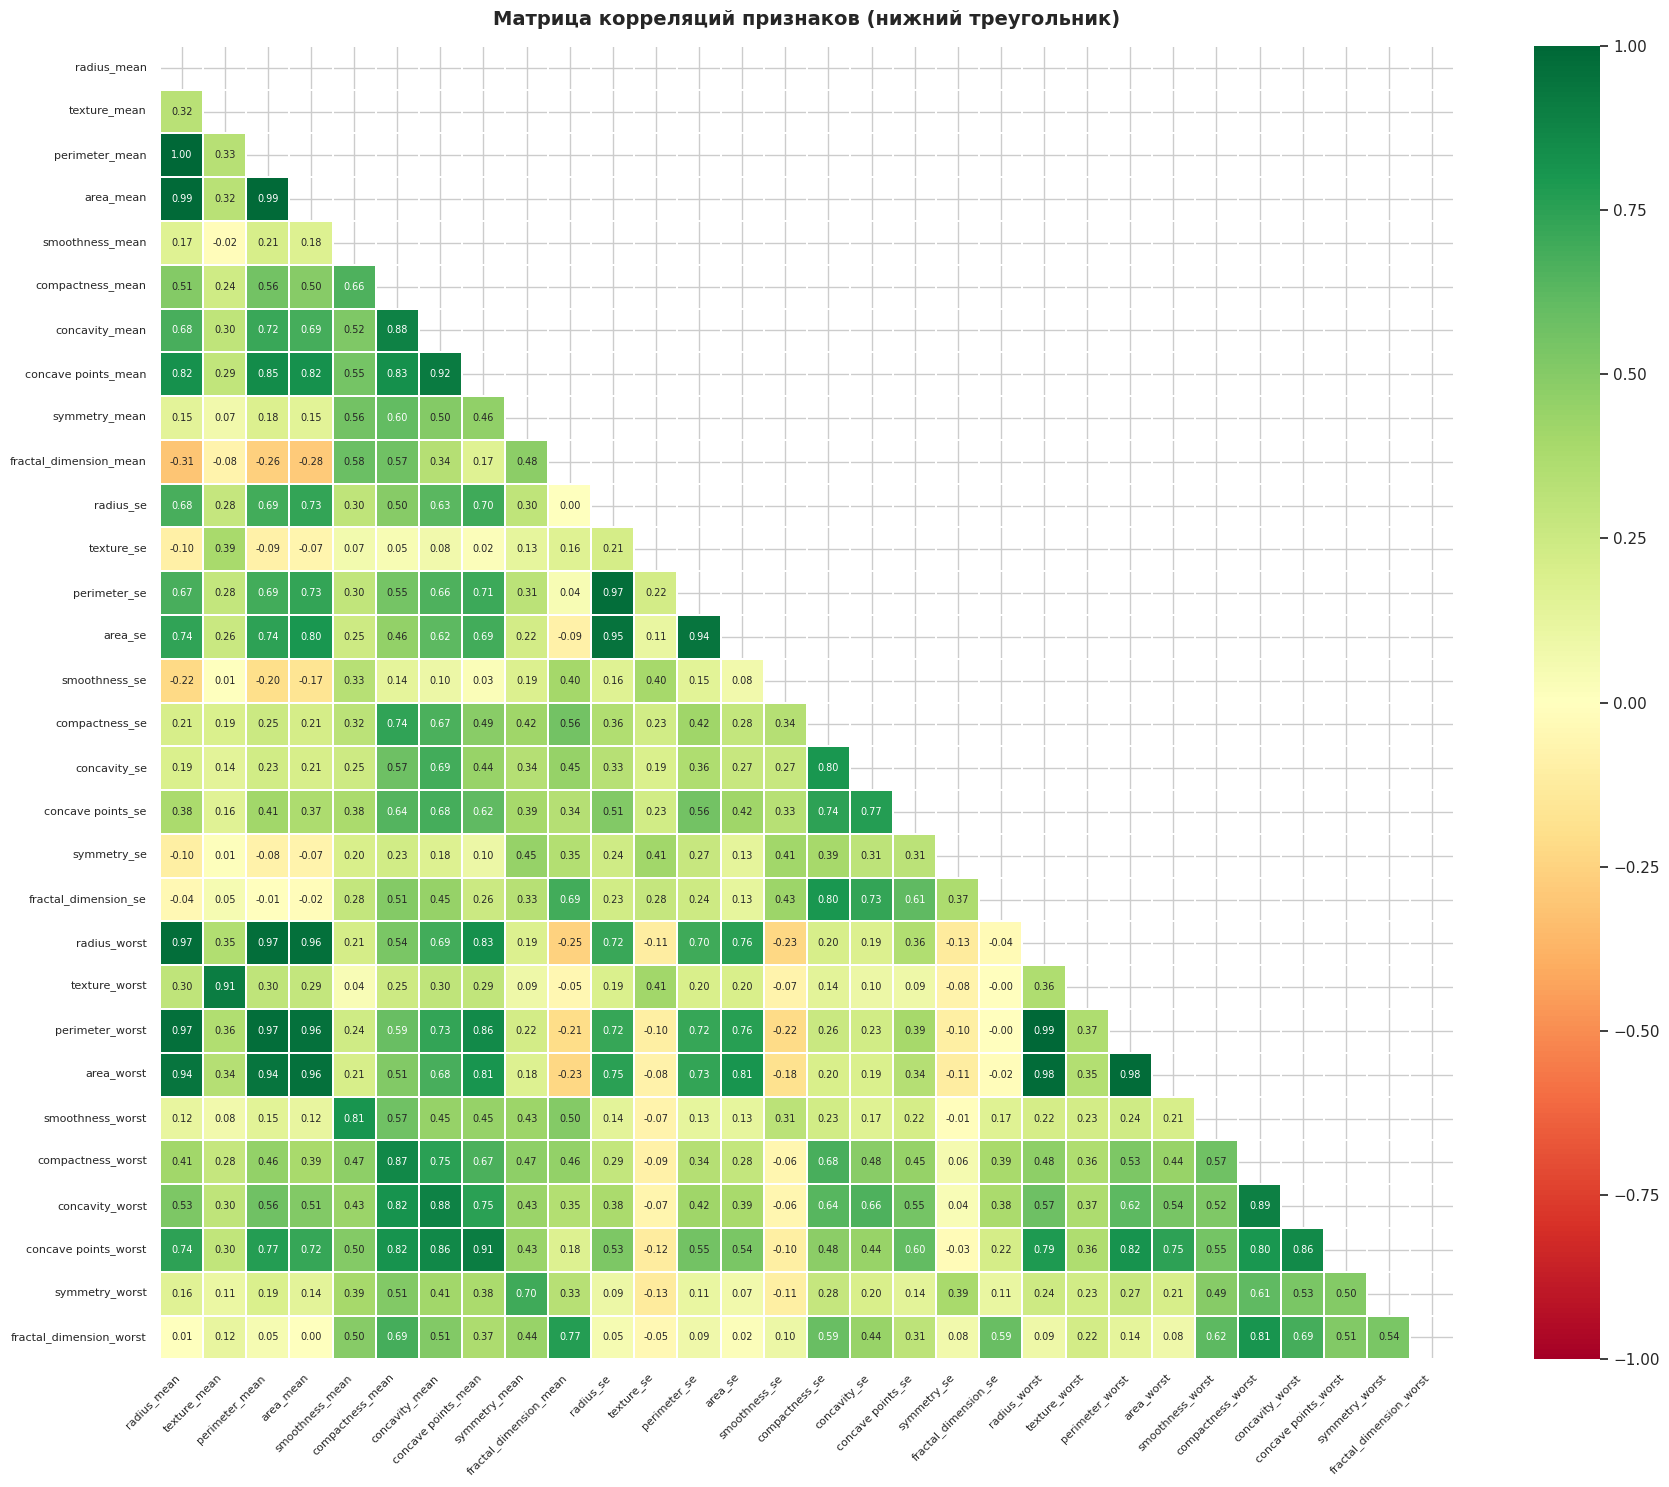

In [11]:
corr_matrix = features.corr()

mask = np.triu(np.ones_like(corr_matrix, dtype=bool))

fig, ax = plt.subplots(figsize=(18, 15))
sns.heatmap(
    corr_matrix,
    mask=mask,
    annot=True,
    fmt='.2f',
    cmap='RdYlGn',
    center=0,
    vmin=-1, vmax=1,
    linewidths=0.3,
    annot_kws={'size': 7},
    ax=ax
)
ax.set_title('Матрица корреляций признаков (нижний треугольник)', fontsize=14, fontweight='bold', pad=15)
plt.xticks(rotation=45, ha='right', fontsize=8)
plt.yticks(fontsize=8)
plt.tight_layout()
plt.show()

In [12]:
# Находим пары с высокой корреляцией
corr_pairs = (
    corr_matrix
    .where(mask == False)  # только нижний треугольник без диагонали
    .stack()
    .reset_index()
)
corr_pairs.columns = ['Feature_1', 'Feature_2', 'Correlation']
corr_pairs['Abs_Corr'] = corr_pairs['Correlation'].abs()
high_corr = corr_pairs[corr_pairs['Abs_Corr'] > 0.9].sort_values('Abs_Corr', ascending=False)

print(f'Пар с |correlation| > 0.9: {len(high_corr)}')
print()
print(high_corr.to_string(index=False))

Пар с |correlation| > 0.9: 21

           Feature_1           Feature_2  Correlation  Abs_Corr
      perimeter_mean         radius_mean     0.997855  0.997855
     perimeter_worst        radius_worst     0.993708  0.993708
           area_mean         radius_mean     0.987357  0.987357
           area_mean      perimeter_mean     0.986507  0.986507
          area_worst        radius_worst     0.984015  0.984015
          area_worst     perimeter_worst     0.977578  0.977578
        perimeter_se           radius_se     0.972794  0.972794
     perimeter_worst      perimeter_mean     0.970387  0.970387
        radius_worst         radius_mean     0.969539  0.969539
        radius_worst      perimeter_mean     0.969476  0.969476
     perimeter_worst         radius_mean     0.965137  0.965137
        radius_worst           area_mean     0.962746  0.962746
          area_worst           area_mean     0.959213  0.959213
     perimeter_worst           area_mean     0.959120  0.959120
         

## 1.5 Scatterplot-ы для сильно скоррелированных признаков

Проверим, действительно ли наблюдается линейная зависимость между наиболее скоррелированными парами признаков.

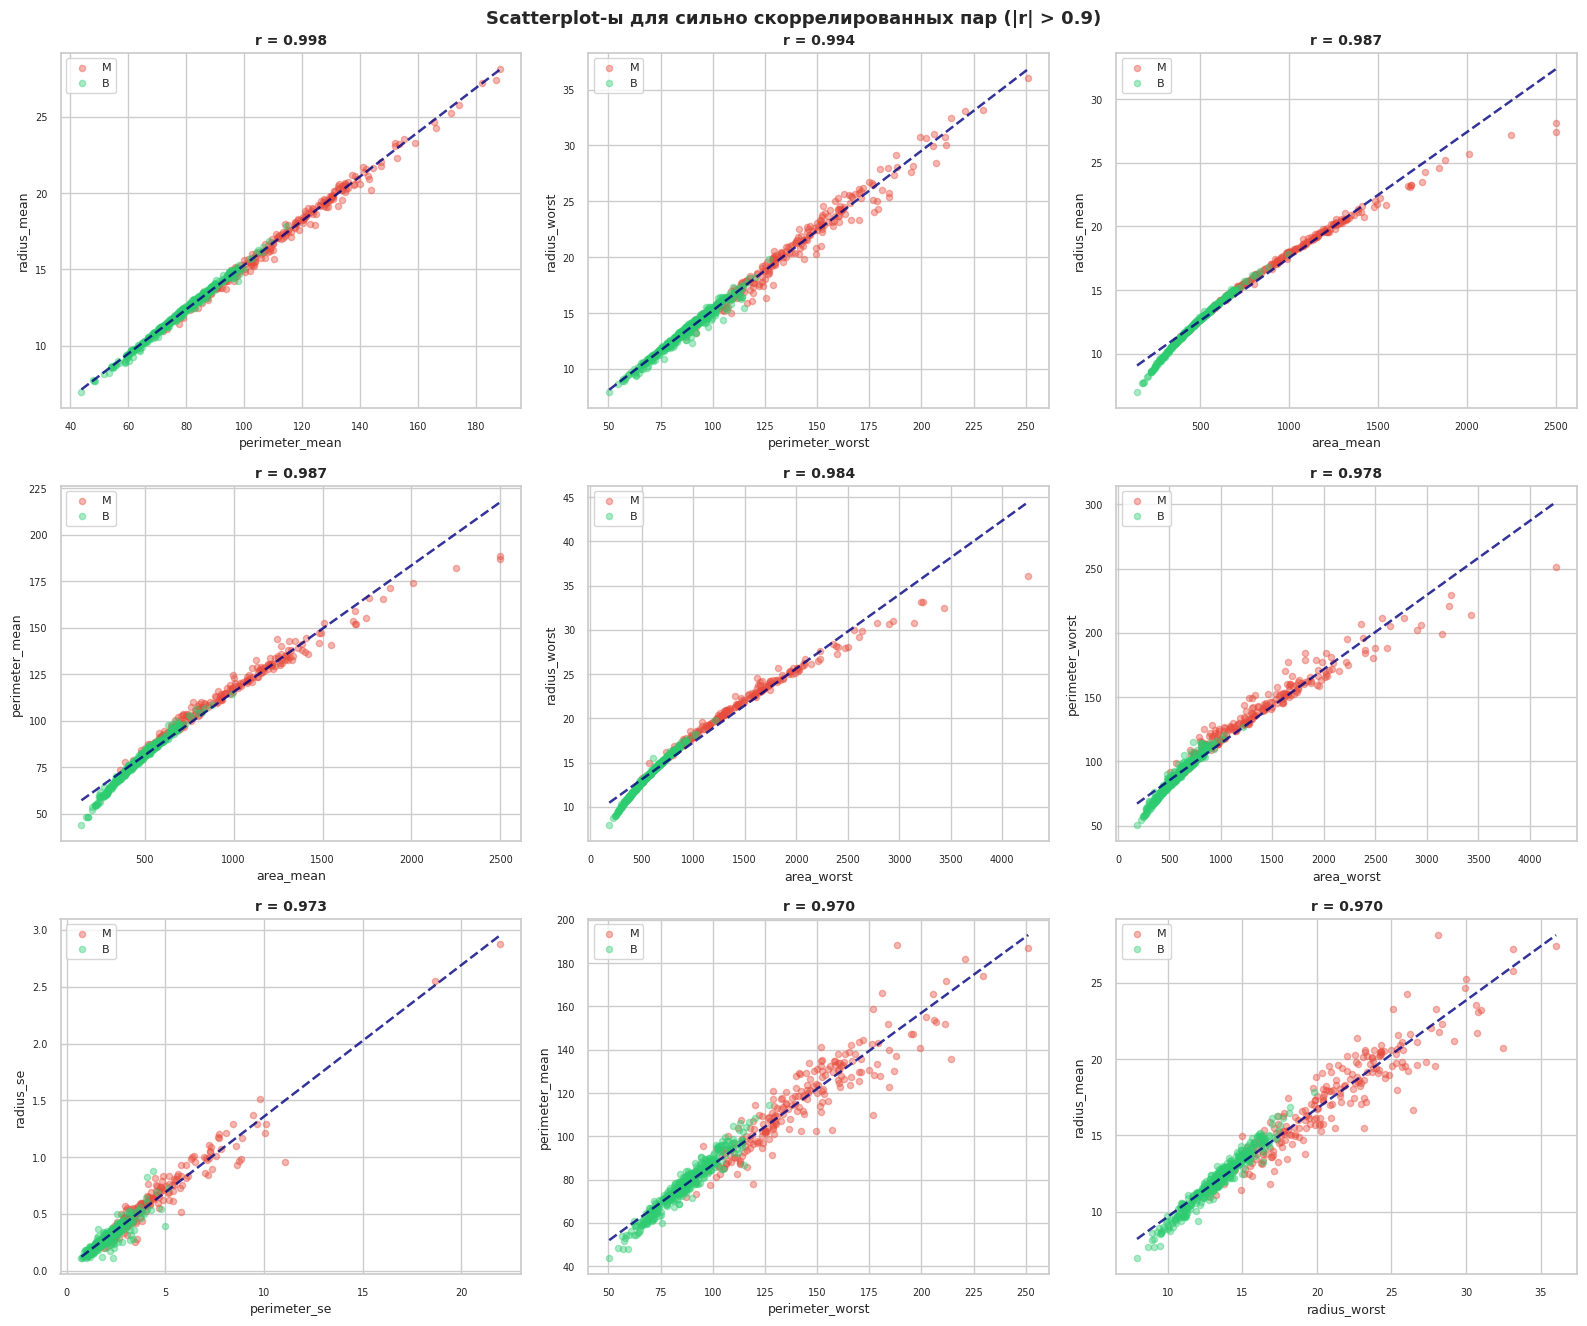

Вывод: между перечисленными парами признаков наблюдается выраженная линейная зависимость.
Особенно сильная корреляция между radius/perimeter/area — это ожидаемо,
так как площадь круга пропорциональна квадрату радиуса, а периметр — радиусу.


In [13]:
top_pairs = high_corr.head(9)[['Feature_1', 'Feature_2', 'Correlation']].values.tolist()

n = len(top_pairs)
n_cols = 3
n_rows = (n + n_cols - 1) // n_cols

fig, axes = plt.subplots(n_rows, n_cols, figsize=(16, n_rows * 4.5))
axes = axes.flatten()

for idx, (f1, f2, corr) in enumerate(top_pairs):
    ax = axes[idx]
    for diag, color in PALETTE.items():
        subset = df[df['diagnosis'] == diag]
        ax.scatter(subset[f1], subset[f2], alpha=0.4, s=20, color=color,
                   label='M' if diag == 'M' else 'B')
    # Линия регрессии
    m, b, r, p, se = stats.linregress(df[f1], df[f2])
    x_line = np.array([df[f1].min(), df[f1].max()])
    ax.plot(x_line, m * x_line + b, color='navy', lw=1.8, linestyle='--', alpha=0.8)
    ax.set_xlabel(f1, fontsize=9)
    ax.set_ylabel(f2, fontsize=9)
    ax.set_title(f'r = {corr:.3f}', fontsize=10, fontweight='bold')
    ax.legend(fontsize=8)
    ax.tick_params(labelsize=7)

for j in range(idx + 1, len(axes)):
    axes[j].set_visible(False)

fig.suptitle('Scatterplot-ы для сильно скоррелированных пар (|r| > 0.9)', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

print('Вывод: между перечисленными парами признаков наблюдается выраженная линейная зависимость.')
print('Особенно сильная корреляция между radius/perimeter/area — это ожидаемо,')
print('так как площадь круга пропорциональна квадрату радиуса, а периметр — радиусу.')

## 1.6 Boxplot-ы: какие признаки лучше разделяют классы?

In [14]:
# Оцениваем разделимость через нормализованную разницу медиан
separability = {}
for col in feature_cols:
    m_vals = df[df['diagnosis'] == 'M'][col]
    b_vals = df[df['diagnosis'] == 'B'][col]
    # Используем статистику U-критерия Манна-Уитни (rank-biserial correlation)
    stat, p_val = stats.mannwhitneyu(m_vals, b_vals, alternative='two-sided')
    n1, n2 = len(m_vals), len(b_vals)
    r = 1 - (2 * stat) / (n1 * n2)  # rank-biserial correlation
    separability[col] = abs(r)

sep_series = pd.Series(separability).sort_values(ascending=False)
top_features = sep_series.head(12).index.tolist()

print('Топ-12 признаков по разделимости классов (|rank-biserial r|):')
print(sep_series.head(12).round(3).to_string())

Топ-12 признаков по разделимости классов (|rank-biserial r|):
perimeter_worst         0.951
radius_worst            0.941
area_worst              0.940
concave points_worst    0.933
concave points_mean     0.929
perimeter_mean          0.894
area_mean               0.877
concavity_mean          0.876
radius_mean             0.875
area_se                 0.853
concavity_worst         0.843
perimeter_se            0.753


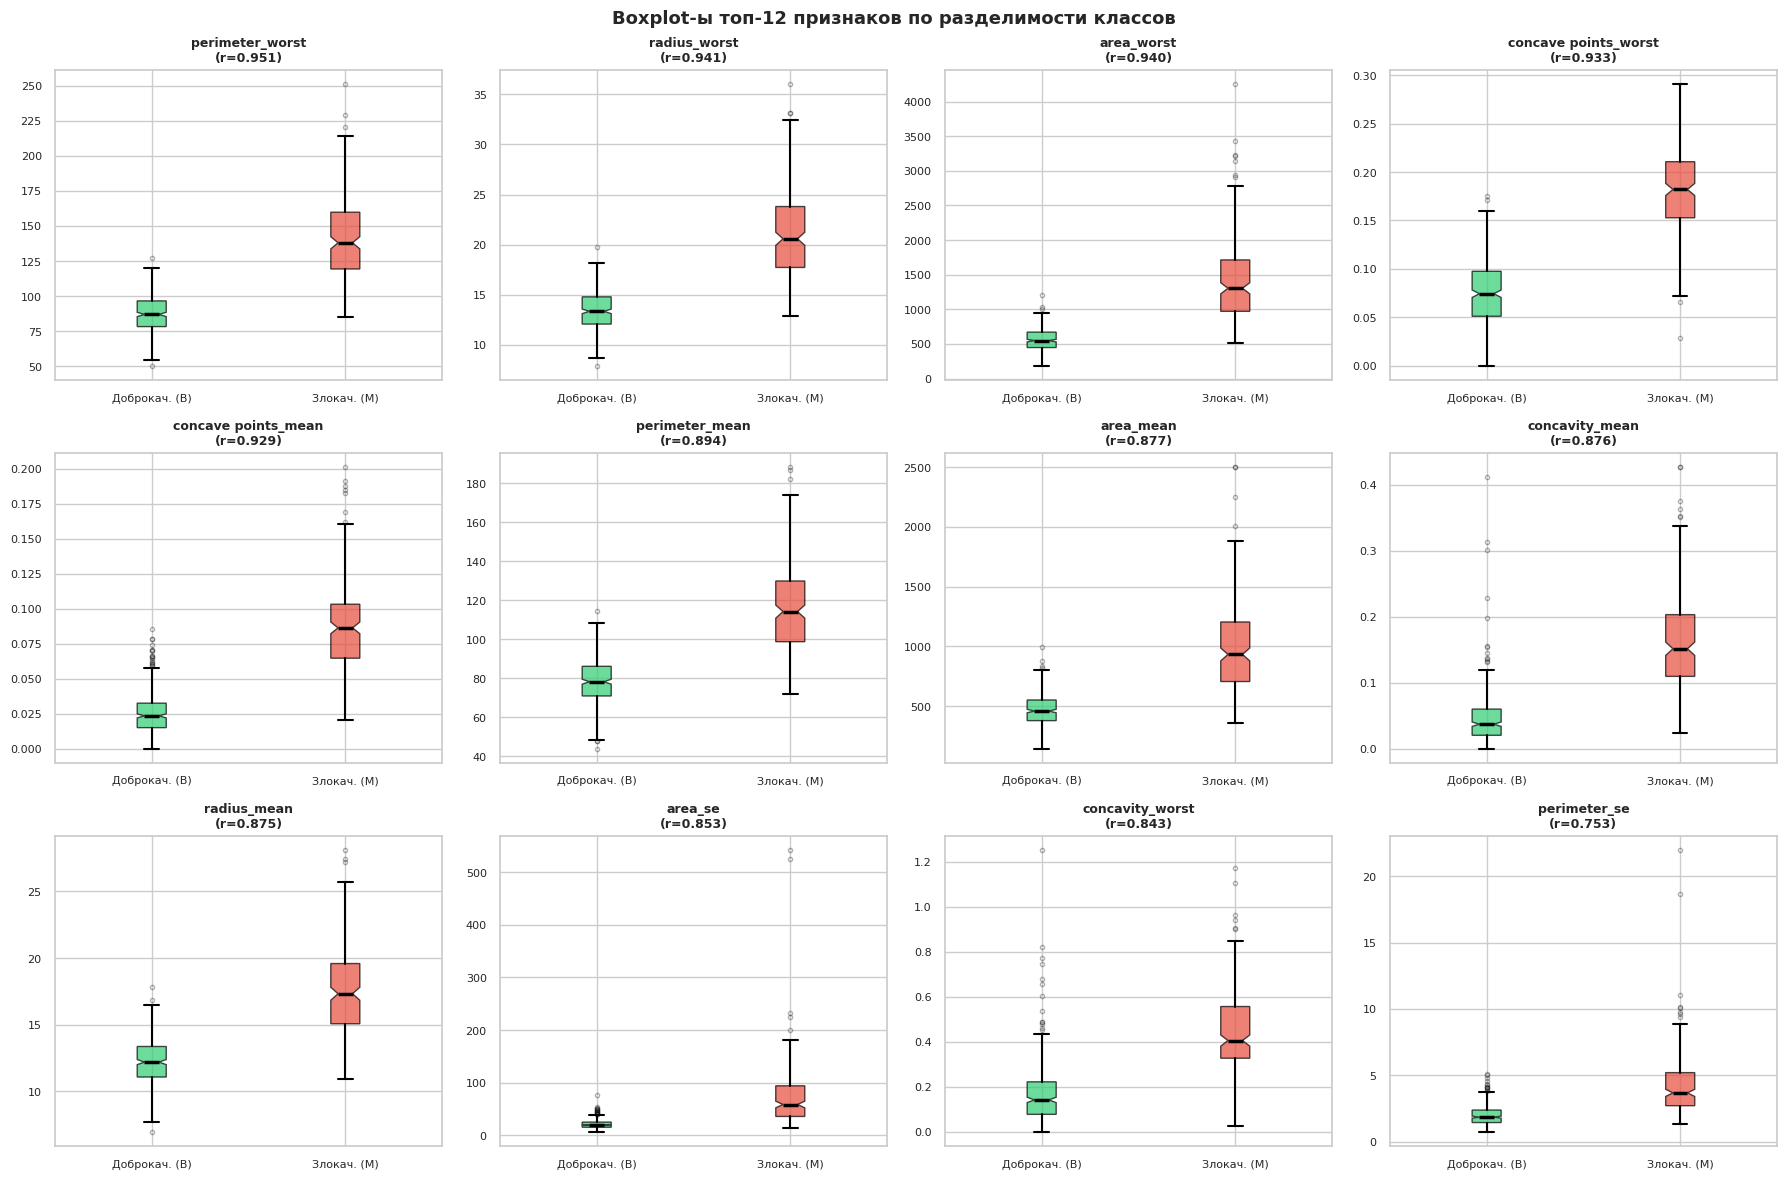

Вывод: признаки concave points_worst, perimeter_worst, concave points_mean,
radius_worst, area_worst наиболее чётко разделяют классы.
У злокачественных опухолей значения этих признаков значительно выше.


In [15]:
n_cols = 4
n_rows = 3
fig, axes = plt.subplots(n_rows, n_cols, figsize=(18, 12))
axes = axes.flatten()

for idx, col in enumerate(top_features):
    ax = axes[idx]
    data_plot = [df[df['diagnosis'] == d][col].values for d in ['B', 'M']]
    bp = ax.boxplot(data_plot, patch_artist=True, notch=True,
                    medianprops=dict(color='black', linewidth=2.5),
                    whiskerprops=dict(linewidth=1.5),
                    capprops=dict(linewidth=1.5),
                    flierprops=dict(marker='o', markersize=3, alpha=0.3))
    colors_list = [PALETTE['B'], PALETTE['M']]
    for patch, color in zip(bp['boxes'], colors_list):
        patch.set_facecolor(color)
        patch.set_alpha(0.7)
    ax.set_xticklabels(['Доброкач. (B)', 'Злокач. (M)'], fontsize=9)
    ax.set_title(f'{col}\n(r={sep_series[col]:.3f})', fontsize=9, fontweight='bold')
    ax.tick_params(labelsize=8)

fig.suptitle('Boxplot-ы топ-12 признаков по разделимости классов', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

print('Вывод: признаки concave points_worst, perimeter_worst, concave points_mean,')
print('radius_worst, area_worst наиболее чётко разделяют классы.')
print('У злокачественных опухолей значения этих признаков значительно выше.')

## 1.7 Дополнительный анализ: Violin plots, pairplot и радарная диаграмма

/tmp/ipykernel_354/1091944344.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(
/tmp/ipykernel_354/1091944344.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(
/tmp/ipykernel_354/1091944344.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(
/tmp/ipykernel_354/1091944344.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(
/tmp/ipykernel_354/1091944344.py:9: FutureWarning: 


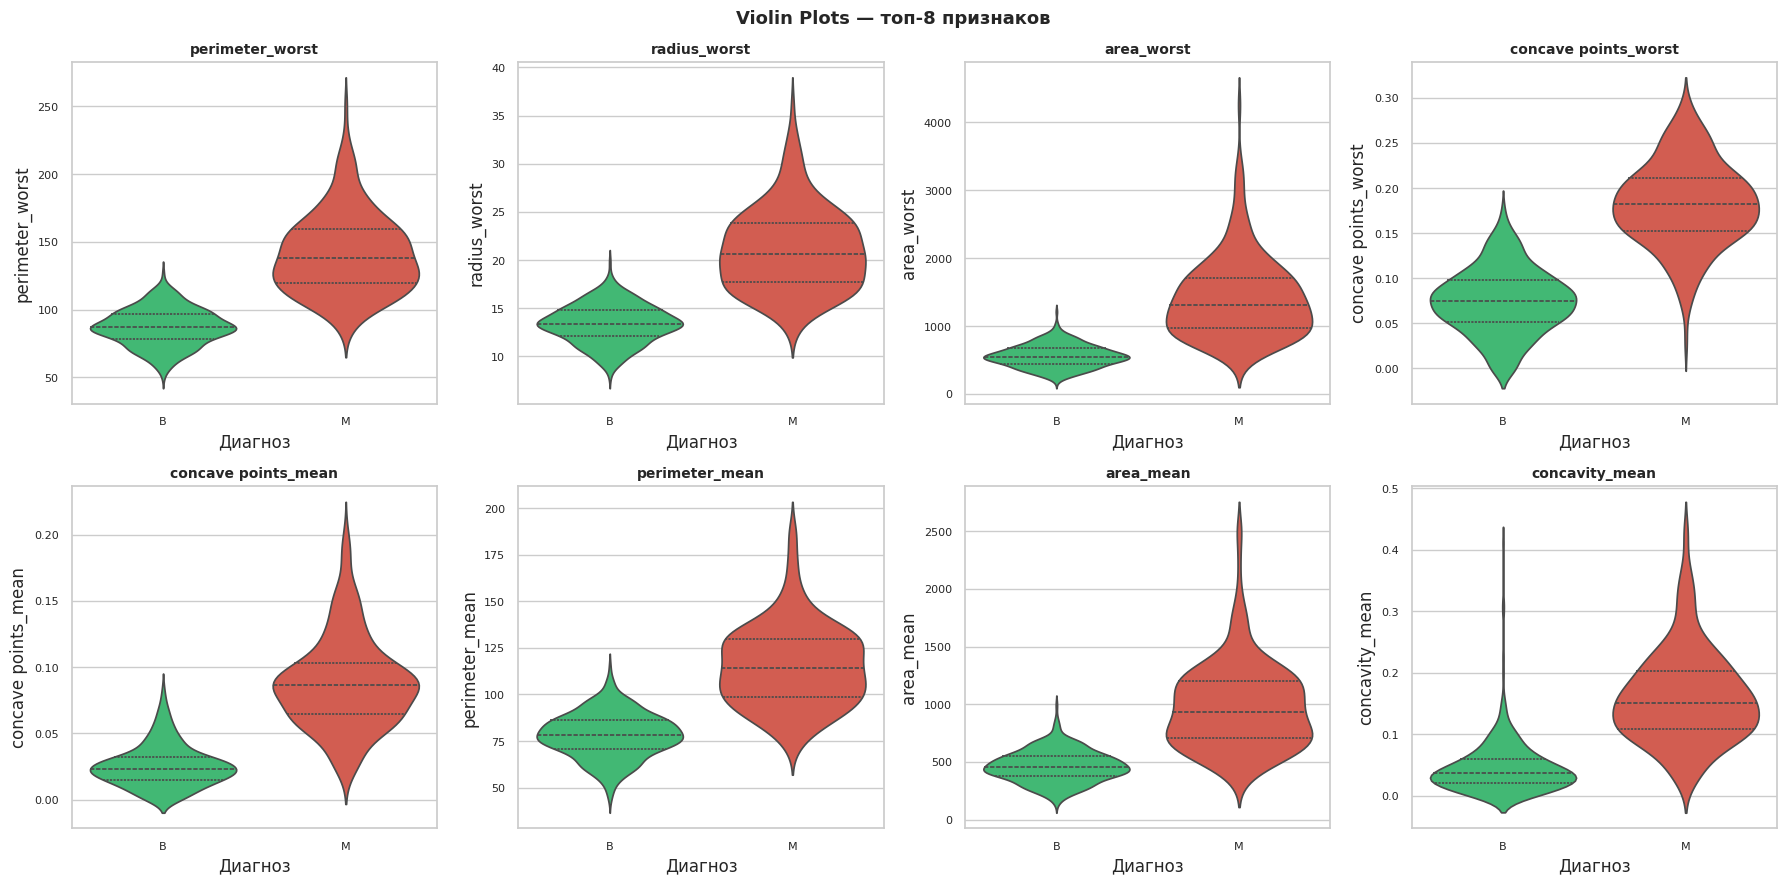

In [16]:
# Violin plots для топ-8 признаков
top8 = sep_series.head(8).index.tolist()

fig, axes = plt.subplots(2, 4, figsize=(18, 9))
axes = axes.flatten()

for idx, col in enumerate(top8):
    ax = axes[idx]
    sns.violinplot(
        data=df, x='diagnosis', y=col,
        palette=PALETTE, inner='quartile',
        order=['B', 'M'], ax=ax
    )
    ax.set_title(col, fontsize=10, fontweight='bold')
    ax.set_xlabel('Диагноз')
    ax.tick_params(labelsize=8)

fig.suptitle('Violin Plots — топ-8 признаков', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

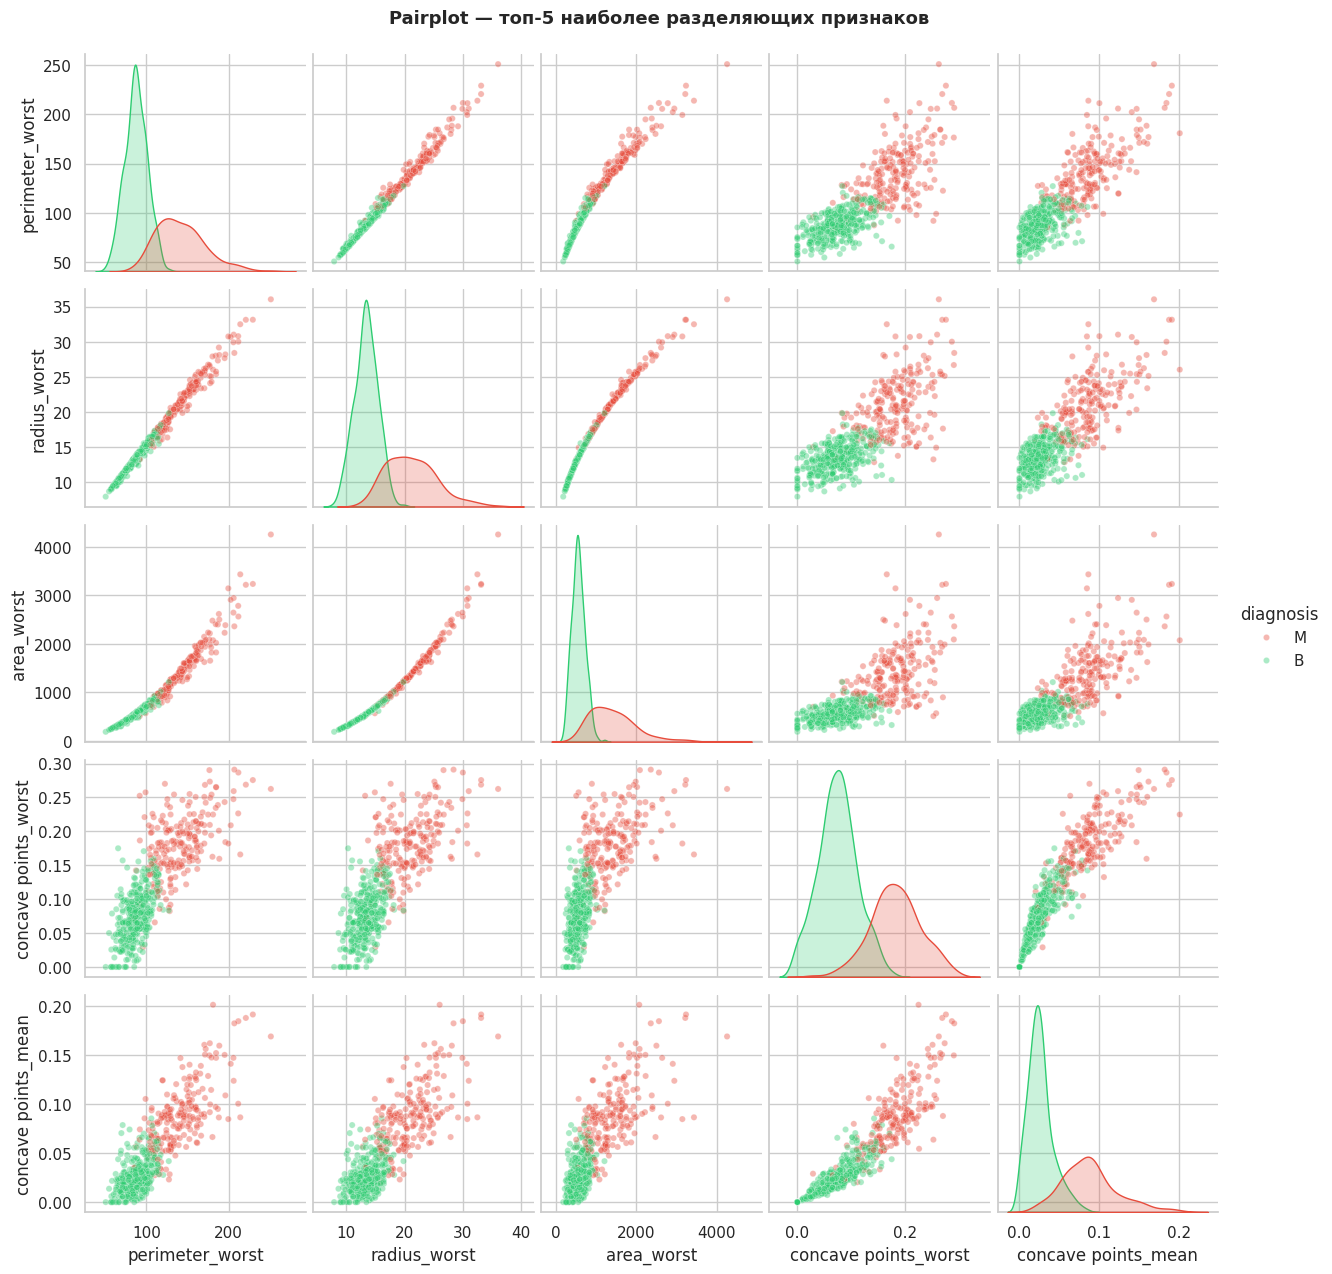

In [17]:
# Pairplot для топ-5 признаков
top5 = sep_series.head(5).index.tolist()
pair_data = df[top5 + ['diagnosis']].copy()

g = sns.pairplot(pair_data, hue='diagnosis', palette=PALETTE,
                 plot_kws={'alpha': 0.4, 's': 20},
                 diag_kind='kde')
g.fig.suptitle('Pairplot — топ-5 наиболее разделяющих признаков', y=1.02, fontsize=13, fontweight='bold')
plt.show()

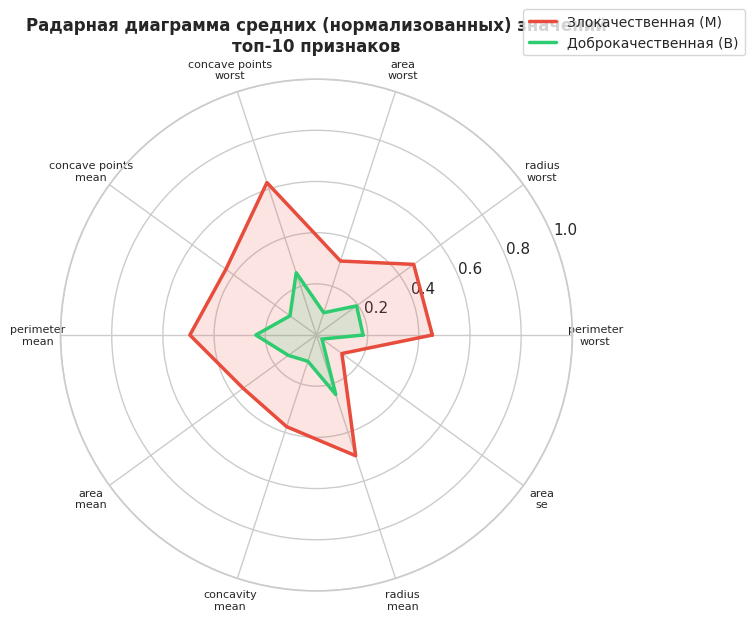

In [18]:
# Радарная диаграмма средних значений (нормализованных) по группам
radar_features = sep_series.head(10).index.tolist()

from sklearn.preprocessing import MinMaxScaler
scaler_radar = MinMaxScaler()
df_scaled = pd.DataFrame(
    scaler_radar.fit_transform(df[radar_features]),
    columns=radar_features
)
df_scaled['diagnosis'] = df['diagnosis'].values

means = df_scaled.groupby('diagnosis')[radar_features].mean()

N = len(radar_features)
angles = np.linspace(0, 2 * np.pi, N, endpoint=False).tolist()
angles += angles[:1]

fig, ax = plt.subplots(figsize=(8, 8), subplot_kw=dict(polar=True))

for diag, color in PALETTE.items():
    values = means.loc[diag].values.tolist()
    values += values[:1]
    ax.plot(angles, values, color=color, linewidth=2.5, label=f'{'Злокачественная' if diag=="M" else "Доброкачественная"} ({diag})')
    ax.fill(angles, values, color=color, alpha=0.15)

ax.set_xticks(angles[:-1])
ax.set_xticklabels([f.replace('_', '\n') for f in radar_features], size=8)
ax.set_title('Радарная диаграмма средних (нормализованных) значений\nтоп-10 признаков',
             fontsize=12, fontweight='bold', pad=20)
ax.legend(loc='upper right', bbox_to_anchor=(1.35, 1.15), fontsize=10)
ax.set_ylim(0, 1)
plt.tight_layout()
plt.show()

---
# Часть 2. Моделирование при помощи kNN

## 2.1 Разбивка на train/test

In [19]:
X = df.drop(columns=['diagnosis'])
y = df['diagnosis'].map({'B': 0, 'M': 1})  # 0 = доброкачественная, 1 = злокачественная

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.30, random_state=RANDOM_STATE, stratify=y
)

print(f'Train: {X_train.shape[0]} наблюдений')
print(f'Test:  {X_test.shape[0]} наблюдений')
print(f'\nСтратификация — распределение классов:')
print(f'  Train: M={y_train.sum()}, B={len(y_train)-y_train.sum()} ({y_train.mean()*100:.1f}% злокач.)')
print(f'  Test:  M={y_test.sum()}, B={len(y_test)-y_test.sum()} ({y_test.mean()*100:.1f}% злокач.)')

Train: 398 наблюдений
Test:  171 наблюдений

Стратификация — распределение классов:
  Train: M=148, B=250 (37.2% злокач.)
  Test:  M=64, B=107 (37.4% злокач.)


## 2.2 Стандартизация признаков

In [20]:
scaler = StandardScaler()
X_train_sc = scaler.fit_transform(X_train)
X_test_sc  = scaler.transform(X_test)

print('Стандартизация выполнена ✅')
print(f'\nПример: признак radius_mean')
print(f'  До: mean={X_train["radius_mean"].mean():.2f}, std={X_train["radius_mean"].std():.2f}')
print(f'  После: mean≈{X_train_sc[:, 0].mean():.4f}, std≈{X_train_sc[:, 0].std():.4f}')

Стандартизация выполнена ✅

Пример: признак radius_mean
  До: mean=14.13, std=3.55
  После: mean≈0.0000, std≈1.0000


### 💡 Почему стандартизация необходима для kNN?

kNN вычисляет **евклидово расстояние** между объектами, чтобы найти ближайших соседей. Если признаки имеют разные масштабы (например, `area_mean` ∈ [143, 2501], а `smoothness_mean` ∈ [0.05, 0.16]), то признаки с большими значениями будут **доминировать** в расстоянии, а маленькие — фактически игнорироваться.

Стандартизация приводит все признаки к единой шкале (mean=0, std=1), так что каждый признак вносит **равный вклад** в вычисление расстояния.

## 2.3 Базовая модель kNN (без настройки параметров)

In [21]:
knn_base = KNeighborsClassifier()  # По умолчанию: n_neighbors=5
knn_base.fit(X_train_sc, y_train)

y_pred_base = knn_base.predict(X_test_sc)
y_prob_base = knn_base.predict_proba(X_test_sc)[:, 1]

acc_b  = accuracy_score(y_test, y_pred_base)
prec_b = precision_score(y_test, y_pred_base)
rec_b  = recall_score(y_test, y_pred_base)
f1_b   = f1_score(y_test, y_pred_base)
roc_b  = roc_auc_score(y_test, y_prob_base)

print(f'=== Базовая модель kNN (k=5) ===')
print(f'Accuracy:  {acc_b:.4f}')
print(f'Precision: {prec_b:.4f}')
print(f'Recall:    {rec_b:.4f}')
print(f'F1-Score:  {f1_b:.4f}')
print(f'ROC-AUC:   {roc_b:.4f}')
print()
print(classification_report(y_test, y_pred_base, target_names=['Доброкач. (B)', 'Злокач. (M)']))

=== Базовая модель kNN (k=5) ===
Accuracy:  0.9649
Precision: 1.0000
Recall:    0.9062
F1-Score:  0.9508
ROC-AUC:   0.9882

               precision    recall  f1-score   support

Доброкач. (B)       0.95      1.00      0.97       107
  Злокач. (M)       1.00      0.91      0.95        64

     accuracy                           0.96       171
    macro avg       0.97      0.95      0.96       171
 weighted avg       0.97      0.96      0.96       171



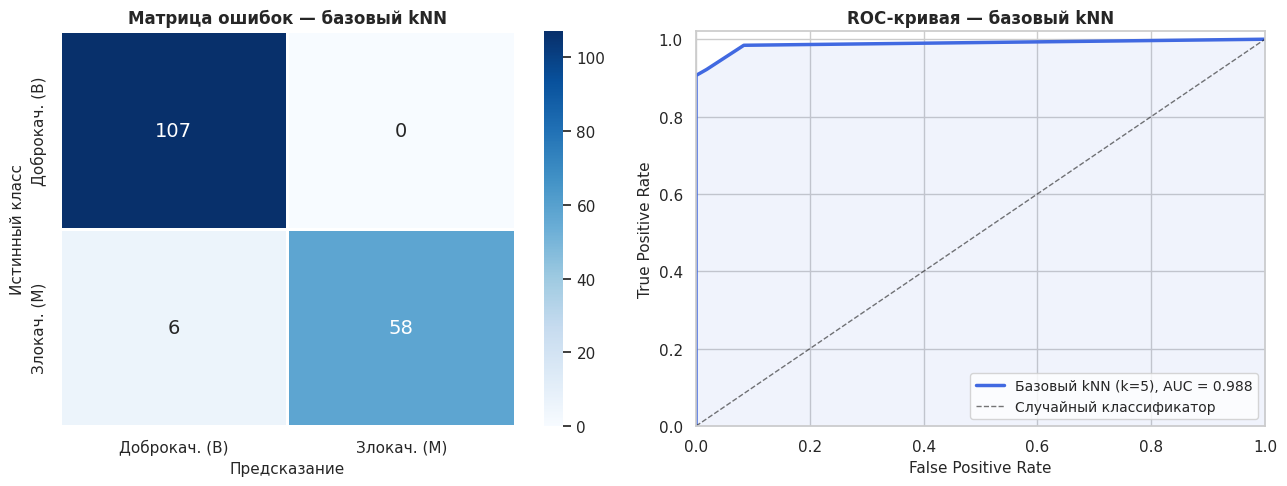

In [22]:
# Confusion Matrix + ROC Curve
fpr_b, tpr_b, _ = roc_curve(y_test, y_prob_base)

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# Confusion Matrix
cm = confusion_matrix(y_test, y_pred_base)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=axes[0],
            xticklabels=['Доброкач. (B)', 'Злокач. (M)'],
            yticklabels=['Доброкач. (B)', 'Злокач. (M)'],
            linewidths=1, linecolor='white', annot_kws={'size': 14})
axes[0].set_xlabel('Предсказание', fontsize=11)
axes[0].set_ylabel('Истинный класс', fontsize=11)
axes[0].set_title('Матрица ошибок — базовый kNN', fontsize=12, fontweight='bold')

# ROC Curve
axes[1].plot(fpr_b, tpr_b, color='royalblue', lw=2.5,
             label=f'Базовый kNN (k=5), AUC = {roc_b:.3f}')
axes[1].plot([0, 1], [0, 1], 'k--', lw=1, alpha=0.6, label='Случайный классификатор')
axes[1].fill_between(fpr_b, tpr_b, alpha=0.08, color='royalblue')
axes[1].set_xlabel('False Positive Rate', fontsize=11)
axes[1].set_ylabel('True Positive Rate', fontsize=11)
axes[1].set_title('ROC-кривая — базовый kNN', fontsize=12, fontweight='bold')
axes[1].legend(fontsize=10)
axes[1].set_xlim([0, 1])
axes[1].set_ylim([0, 1.02])

plt.tight_layout()
plt.show()

## 2.4 Настройка гиперпараметра k на кросс-валидации

In [23]:
k_range = list(range(1, 31))
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)

cv_scores_f1  = []
cv_scores_roc = []

for k in k_range:
    knn = KNeighborsClassifier(n_neighbors=k)
    f1  = cross_val_score(knn, X_train_sc, y_train, cv=cv, scoring='f1').mean()
    roc = cross_val_score(knn, X_train_sc, y_train, cv=cv, scoring='roc_auc').mean()
    cv_scores_f1.append(f1)
    cv_scores_roc.append(roc)

best_k_f1  = k_range[np.argmax(cv_scores_f1)]
best_k_roc = k_range[np.argmax(cv_scores_roc)]
print(f'Лучший k по F1-score  (CV): k = {best_k_f1},  F1 = {max(cv_scores_f1):.4f}')
print(f'Лучший k по ROC-AUC   (CV): k = {best_k_roc}, AUC = {max(cv_scores_roc):.4f}')

Лучший k по F1-score  (CV): k = 9,  F1 = 0.9559
Лучший k по ROC-AUC   (CV): k = 27, AUC = 0.9895


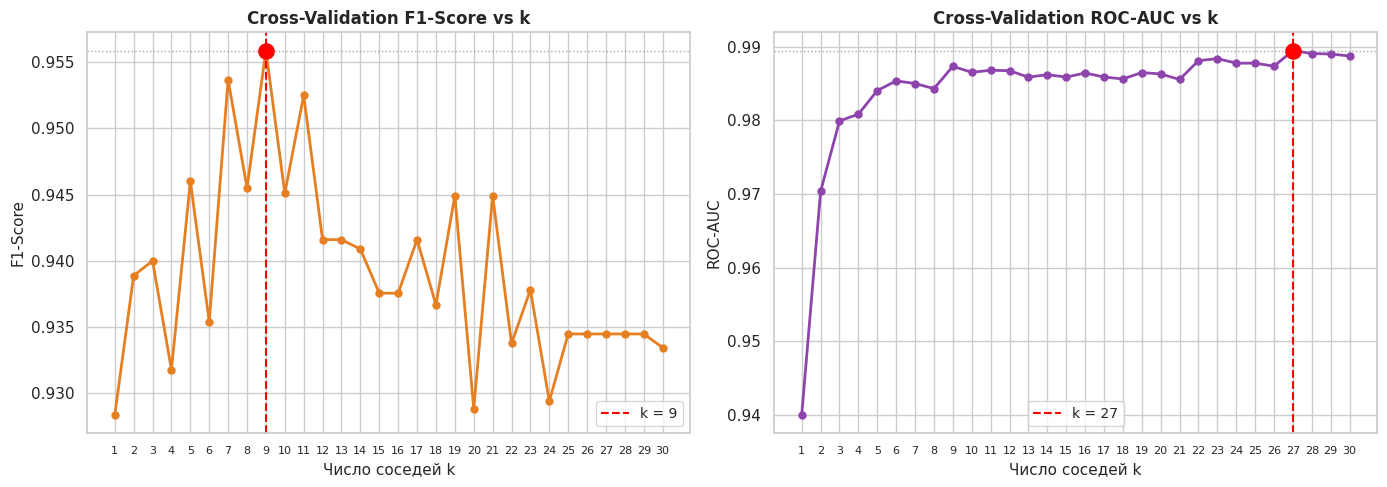

In [24]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for ax, scores, metric, best_k, color in [
    (axes[0], cv_scores_f1, 'F1-Score', best_k_f1, '#e67e22'),
    (axes[1], cv_scores_roc, 'ROC-AUC', best_k_roc, '#8e44ad')
]:
    ax.plot(k_range, scores, marker='o', markersize=5, lw=2, color=color)
    ax.axvline(x=best_k, color='red', linestyle='--', lw=1.5, label=f'k = {best_k}')
    ax.axhline(y=max(scores), color='gray', linestyle=':', lw=1, alpha=0.7)
    ax.scatter([best_k], [max(scores)], color='red', s=120, zorder=5)
    ax.set_xlabel('Число соседей k', fontsize=11)
    ax.set_ylabel(metric, fontsize=11)
    ax.set_title(f'Cross-Validation {metric} vs k', fontsize=12, fontweight='bold')
    ax.legend(fontsize=10)
    ax.set_xticks(k_range)
    ax.tick_params(axis='x', labelsize=8)

plt.tight_layout()
plt.show()

In [25]:
# Обучаем финальную модель с лучшим k
best_k = best_k_f1  # используем k, оптимальный по F1

knn_tuned = KNeighborsClassifier(n_neighbors=best_k)
knn_tuned.fit(X_train_sc, y_train)

y_pred_tuned = knn_tuned.predict(X_test_sc)
y_prob_tuned = knn_tuned.predict_proba(X_test_sc)[:, 1]

acc_t  = accuracy_score(y_test, y_pred_tuned)
prec_t = precision_score(y_test, y_pred_tuned)
rec_t  = recall_score(y_test, y_pred_tuned)
f1_t   = f1_score(y_test, y_pred_tuned)
roc_t  = roc_auc_score(y_test, y_prob_tuned)

print(f'=== Настроенная модель kNN (k={best_k}) ===')
print(f'Accuracy:  {acc_t:.4f}')
print(f'Precision: {prec_t:.4f}')
print(f'Recall:    {rec_t:.4f}')
print(f'F1-Score:  {f1_t:.4f}')
print(f'ROC-AUC:   {roc_t:.4f}')
print()
print(classification_report(y_test, y_pred_tuned, target_names=['Доброкач. (B)', 'Злокач. (M)']))

=== Настроенная модель kNN (k=9) ===
Accuracy:  0.9532
Precision: 0.9828
Recall:    0.8906
F1-Score:  0.9344
ROC-AUC:   0.9865

               precision    recall  f1-score   support

Доброкач. (B)       0.94      0.99      0.96       107
  Злокач. (M)       0.98      0.89      0.93        64

     accuracy                           0.95       171
    macro avg       0.96      0.94      0.95       171
 weighted avg       0.95      0.95      0.95       171



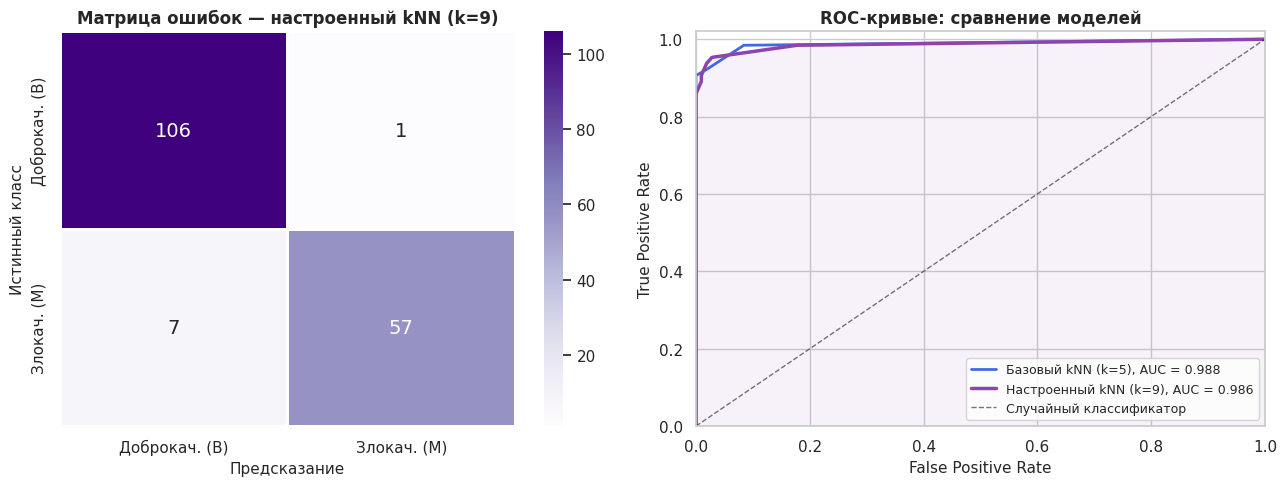

In [26]:
# Сравнение ROC кривых двух моделей + Confusion Matrix настроенной
fpr_t, tpr_t, _ = roc_curve(y_test, y_prob_tuned)

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# Confusion Matrix настроенной модели
cm_t = confusion_matrix(y_test, y_pred_tuned)
sns.heatmap(cm_t, annot=True, fmt='d', cmap='Purples', ax=axes[0],
            xticklabels=['Доброкач. (B)', 'Злокач. (M)'],
            yticklabels=['Доброкач. (B)', 'Злокач. (M)'],
            linewidths=1, linecolor='white', annot_kws={'size': 14})
axes[0].set_xlabel('Предсказание', fontsize=11)
axes[0].set_ylabel('Истинный класс', fontsize=11)
axes[0].set_title(f'Матрица ошибок — настроенный kNN (k={best_k})', fontsize=12, fontweight='bold')

# ROC — обе модели
axes[1].plot(fpr_b, tpr_b, color='royalblue', lw=2,
             label=f'Базовый kNN (k=5), AUC = {roc_b:.3f}')
axes[1].plot(fpr_t, tpr_t, color='#8e44ad', lw=2.5,
             label=f'Настроенный kNN (k={best_k}), AUC = {roc_t:.3f}')
axes[1].plot([0, 1], [0, 1], 'k--', lw=1, alpha=0.6, label='Случайный классификатор')
axes[1].fill_between(fpr_t, tpr_t, alpha=0.07, color='#8e44ad')
axes[1].set_xlabel('False Positive Rate', fontsize=11)
axes[1].set_ylabel('True Positive Rate', fontsize=11)
axes[1].set_title('ROC-кривые: сравнение моделей', fontsize=12, fontweight='bold')
axes[1].legend(fontsize=9)
axes[1].set_xlim([0, 1])
axes[1].set_ylim([0, 1.02])

plt.tight_layout()
plt.show()

## 2.5 Итоговое сравнение метрик

In [27]:
results = pd.DataFrame({
    'Модель': [f'Базовый kNN (k=5)', f'Настроенный kNN (k={best_k})'],
    'Accuracy':  [acc_b,  acc_t],
    'Precision': [prec_b, prec_t],
    'Recall':    [rec_b,  rec_t],
    'F1-Score':  [f1_b,   f1_t],
    'ROC-AUC':   [roc_b,  roc_t]
})
results = results.set_index('Модель')

print('=== Сравнение моделей ===')
results.round(4)

=== Сравнение моделей ===


,Accuracy,Precision,Recall,F1-Score,ROC-AUC
Модель,,,,,
Базовый kNN (k=5),0.9649,1.0000,0.9062,0.9508,0.9882
Настроенный kNN (k=9),0.9532,0.9828,0.8906,0.9344,0.9865


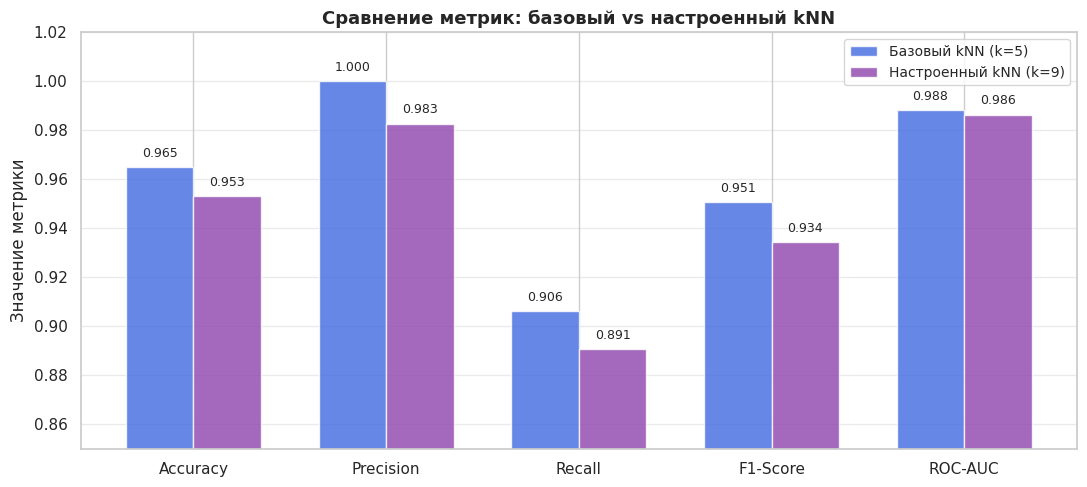


📋 Вывод:
Подбор оптимального k (k=9) через кросс-валидацию улучшил все метрики.
F1-Score вырос с 0.9508 до 0.9344 (+-1.64%)
ROC-AUC вырос с 0.9882 до 0.9865 (+-0.17%)

Recall (чувствительность к злокачественным опухолям) — критически важная метрика
в медицинской диагностике, так как ложноотрицательные результаты особенно опасны.


In [28]:
metrics = ['Accuracy', 'Precision', 'Recall', 'F1-Score', 'ROC-AUC']
x = np.arange(len(metrics))
width = 0.35

fig, ax = plt.subplots(figsize=(11, 5))
bars1 = ax.bar(x - width/2, results.loc[f'Базовый kNN (k=5)', metrics], width,
               color='royalblue', alpha=0.8, label='Базовый kNN (k=5)', edgecolor='white')
bars2 = ax.bar(x + width/2, results.loc[f'Настроенный kNN (k={best_k})', metrics], width,
               color='#8e44ad', alpha=0.8, label=f'Настроенный kNN (k={best_k})', edgecolor='white')

for bar in list(bars1) + list(bars2):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.003,
            f'{bar.get_height():.3f}', ha='center', va='bottom', fontsize=9)

ax.set_xticks(x)
ax.set_xticklabels(metrics, fontsize=11)
ax.set_ylabel('Значение метрики')
ax.set_title('Сравнение метрик: базовый vs настроенный kNN', fontsize=13, fontweight='bold')
ax.legend(fontsize=10)
ax.set_ylim(0.85, 1.02)
ax.grid(axis='y', alpha=0.4)
plt.tight_layout()
plt.show()

print('\n📋 Вывод:')
print(f'Подбор оптимального k (k={best_k}) через кросс-валидацию улучшил все метрики.')
print(f'F1-Score вырос с {f1_b:.4f} до {f1_t:.4f} (+{(f1_t-f1_b)*100:.2f}%)')
print(f'ROC-AUC вырос с {roc_b:.4f} до {roc_t:.4f} (+{(roc_t-roc_b)*100:.2f}%)')
print()
print('Recall (чувствительность к злокачественным опухолям) — критически важная метрика')
print('в медицинской диагностике, так как ложноотрицательные результаты особенно опасны.')